In [1]:
import os

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"  # see issue #152
os.environ["CUDA_VISIBLE_DEVICES"] = "1, 2"

In [2]:
import torch

[torch.cuda.device(i) for i in range(torch.cuda.device_count())]

[<torch.cuda.device at 0x7fe9fa265d30>, <torch.cuda.device at 0x7fe9fa3dac10>]

In [3]:
#%load_ext autoreload
#%autoreload 2

# import os
from os.path import join
import random
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from skimage import measure
from torch.utils.data import Dataset, DataLoader
import torchio as tio
from torchio.data import SubjectsLoader

from monai.networks.nets import UNet, AttentionUnet

# os.environ["CUDA_VISIBLE_DEVICES"] = "1, 2" # TODO: multiple ?
import torch
import torch.nn as nn
from pathlib import Path
from datetime import datetime

from torch.nn import DataParallel

seed = 42


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)


set_seed(seed)

In [4]:
import sys

print('__Python VERSION:', sys.version)
print('__pyTorch VERSION:', torch.__version__)
print('__CUDA VERSION')
from subprocess import call
! nvcc --version
print('__CUDNN VERSION:', torch.backends.cudnn.version())
print('__Number CUDA Devices:', torch.cuda.device_count())
print('__Devices')
call(["nvidia-smi", "--format=csv", "--query-gpu=index,name,driver_version,memory.total,memory.used,memory.free"])
print('Active CUDA Device: GPU', torch.cuda.current_device())
print('Available devices ', torch.cuda.device_count())
print('Current cuda device ', torch.cuda.current_device())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

__Python VERSION: 3.13.2 (main, Feb  5 2025, 19:11:32) [Clang 19.1.6 ]
__pyTorch VERSION: 2.7.1+cu126
__CUDA VERSION
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2021 NVIDIA Corporation
Built on Thu_Nov_18_09:45:30_PST_2021
Cuda compilation tools, release 11.5, V11.5.119
Build cuda_11.5.r11.5/compiler.30672275_0
__CUDNN VERSION: 90501
__Number CUDA Devices: 2
__Devices
index, name, driver_version, memory.total [MiB], memory.used [MiB], memory.free [MiB]
0, NVIDIA A100-SXM4-80GB, 535.129.03, 81920 MiB, 2190 MiB, 78859 MiB
1, NVIDIA A100-SXM4-80GB, 535.129.03, 81920 MiB, 7 MiB, 81042 MiB
2, NVIDIA A100-SXM4-80GB, 535.129.03, 81920 MiB, 7 MiB, 81042 MiB
3, NVIDIA A100-SXM4-80GB, 535.129.03, 81920 MiB, 809 MiB, 80241 MiB
4, NVIDIA A100-SXM4-80GB, 535.129.03, 81920 MiB, 3974 MiB, 77075 MiB
5, NVIDIA A100-SXM4-80GB, 535.129.03, 81920 MiB, 685 MiB, 80365 MiB
6, NVIDIA A100-SXM4-80GB, 535.129.03, 81920 MiB, 31118 MiB, 49932 MiB
7, NVIDIA A100-SXM4-80GB, 535.129.03, 81920 MiB, 35170

In [5]:
from utils.loading_utils import *
from utils.logging import *
from visualization.visualization import *
#from ml.dataset_ import BrainMetDatasetPreloaded, GridSamplerWrapper
from ml.dataset_ import BrainMetPytorchDataset, BrainMetFullVolumeDataset, BrainMetPytorchDatasetValidation
from ml.trainer import Trainer, Att3DUNET_Trainer, load_trained_model

In [6]:
%load_ext tensorboard
%reload_ext tensorboard

%tensorboard --logdir runs

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "/usr/local/bin/tensorboard", line 5, in <module>
    from tensorboard.main import run_main
ModuleNotFoundError: No module named 'tensorboard'

In [7]:
#from tensorboard import notebook
#notebook.list()
#notebook.display(port=6006, height=1000)

#http://127.0.0.1:6006/?darkMode=true

In [8]:
from ml.dataset_ import BrainMetPytorchDataset

TRAIN_ROOT_DIR = './MICCAI-LH-BraTS2025-MET-Challenge-Training/'
HELPER_ROOT_DIR = './training_helper/'

# !--------------------------------------------------------------
dataset = BrainMetPytorchDataset(TRAIN_ROOT_DIR, patch_size=(128, 128, 96), do_raffine=True)
# !--------------------------------------------------------------

train_dataset, validation_dataset = torch.utils.data.random_split(dataset, [0.9, 0.1])

workers = 48
pin_memory = True

train_dataloader = DataLoader(train_dataset, batch_size=16, num_workers=workers, shuffle=True, pin_memory=pin_memory)
validation_dataloader = DataLoader(validation_dataset, batch_size=16, num_workers=workers, shuffle=False, pin_memory=pin_memory)

Found UCSD-Training subfolder: ./MICCAI-LH-BraTS2025-MET-Challenge-Training/UCSD - Training
Total # samples: 1296 in ./MICCAI-LH-BraTS2025-MET-Challenge-Training/



In [9]:
def dice_loss(probs, targets, epsilon=1e-5):
    # Assumes probs: [B, C, H, W, D], targets: [B, C, H, W, D]
    intersection = (probs * targets).sum(dim=(2, 3, 4))
    union = probs.sum(dim=(2, 3, 4)) + targets.sum(dim=(2, 3, 4))
    dice = 2. * intersection / (union + epsilon)
    return 1 - dice.mean()


def loss_fn(logits, target):
    target = target.to(torch.long)
    if target.ndim == 5 and target.shape[1] == 1:
        target = target[:, 0]  # [B, H, W, D]
    ce = torch.nn.functional.cross_entropy(logits, target)

    # --- Dice loss ---
    probs = torch.softmax(logits, dim=1)  # [B, C, H, W, D]
    one_hot_target = torch.nn.functional.one_hot(target, num_classes=logits.shape[1])  # [B, H, W, D, C]
    one_hot_target = one_hot_target.permute(0, 4, 1, 2, 3).float()  # [B, C, H, W, D]

    dice = dice_loss(probs, one_hot_target)

    return ce + dice


def dice_score(preds, targets, epsilon=1e-5):
    if targets.ndim == 5 and targets.shape[1] == 1:
        targets = targets[:, 0]  # Fix channel dim

    num_classes = int(torch.max(targets).item()) + 1
    dice_scores = []

    for c in range(num_classes):
        pred_c = (preds == c).float()
        target_c = (targets == c).float()

        intersection = (pred_c * target_c).sum(dim=(1, 2, 3))
        union = pred_c.sum(dim=(1, 2, 3)) + target_c.sum(dim=(1, 2, 3))

        dice = (2 * intersection + epsilon) / (union + epsilon)
        dice_scores.append(dice)

    return torch.stack(dice_scores).mean()

# Run1

In [10]:
from ml.a3d_attention_unet import UNet3D

model_1 = UNet3D(
    in_channels=4,
    out_channels=5,
    final_sigmoid=False,
    f_maps=32,  # should be 32
    layer_order='crg',
    num_groups=8  # should be 8
).to(device)
#------------------------------------------------------------------
# apparently geht des so leicht....
# TODO: musst aber oben bei dein imports dann einstellen welche visible sin
model_1 = torch.nn.DataParallel(model_1)  #, device_ids=['cuda:1', 'cuda:2'])
#-----------------------------------------------------------------

optimizer_1 = torch.optim.Adam(model_1.parameters(), lr=1.5e-4, weight_decay=5e-3)

Epoch: 1 [valid-loss]: 100%|██████████| 9/9 [01:53<00:00, 12.66s/it, valid-loss_loss=1.8552]



Epoch Summary:
  train-loss: 1.0124
  mean-dice-score: 0.5137
  WT-Dice: 0.6710
  TC-Dice: 0.0762
  ET-Dice: 0.0000
  WT-NSD: 0.1518
  WT-Sensitivity: 0.0054
  WT-Specificity: 0.9956
  WT-Precision: 0.0470
  TC-NSD: 0.1030
  TC-Sensitivity: 0.0006
  TC-Specificity: 0.9991
  TC-Precision: 0.0048
  ET-NSD: 0.1389
  ET-Sensitivity: 0.0000
  ET-Specificity: 1.0000
  ET-Precision: 0.0000
  valid-loss: 1.8552


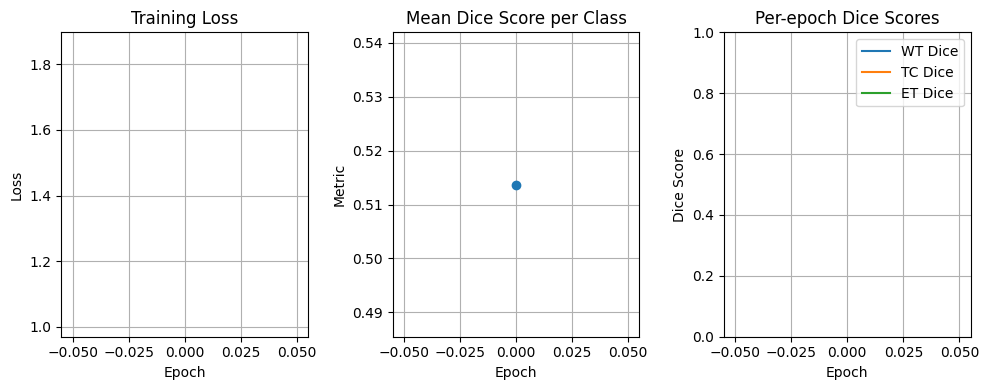

In [11]:
num_epochs = 1  # TODO: change to 50
dir = f'./runs/run_{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}'
progress = ProgressBar()
tb = TensorBoard(path=dir)
checkpoints = Backup(path=dir, every=1)

trainer_1 = Att3DUNET_Trainer(model_1, optimizer_1, loss_fn, dice_score, device=device, use_torchio=False)
checkpoints.attach_trainer(trainer_1)
trainer_1.tracker.loggers = [progress, tb, checkpoints]

trainer_1.train(train_loader=train_dataloader, val_loader=validation_dataloader, epochs=num_epochs)

In [12]:
VALIDATION_ROOT_DIR = './MICCAI-LH-BraTS2025-MET-Challenge-Validation/'

fullval_dataset = BrainMetFullVolumeDataset(root_dir=VALIDATION_ROOT_DIR)
full_validation_dataset = DataLoader(fullval_dataset, batch_size=1, num_workers=workers, shuffle=False, pin_memory=pin_memory)

In [13]:
# === Setup ===
model_1.eval()
timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
save_dir = f"./results/res_nopost_{timestamp}"
os.makedirs(save_dir, exist_ok=True)

# === Inference Loop ===
for i, (inputs, datapoint_name) in enumerate(tqdm(full_validation_dataset, desc="Predicting")):
    inputs = inputs.to("cuda")

    with torch.no_grad():
        logits, _ = model_1(inputs)
        preds = torch.argmax(logits, dim=1)

    pred_np = preds.squeeze(0).cpu().numpy().astype(np.uint8)
    affine = np.eye(4)  # You could optionally load one of the input affines here

    pred_nii = nib.Nifti1Image(pred_np, affine)
    save_path = os.path.join(save_dir, datapoint_name[0] + "-seg.nii.gz")
    nib.save(pred_nii, save_path)

Predicting: 100%|██████████| 179/179 [03:24<00:00,  1.14s/it]


# Post-processing

In [14]:
from scipy.ndimage import label, sum as ndi_sum, binary_closing
from surface_distance import compute_surface_distances


def remove_small_regions(seg, min_size=100):
    result = np.copy(seg)
    for c in np.unique(seg):
        if c == 0: continue
        binary = (seg == c)
        labeled, num = label(binary)
        sizes = ndi_sum(binary, labeled, range(1, num + 1))
        for i, size in enumerate(sizes):
            if size < min_size:
                result[labeled == (i + 1)] = 0
    return result


def morph_close(seg):
    result = np.zeros_like(seg)
    for c in np.unique(seg):
        if c == 0: continue
        binary = (seg == c)
        closed = binary_closing(binary)
        result[closed] = c
    return result


def compute_braTS_dice(pred, target, num_classes=5):
    eps = 1e-5
    dice_scores = {}

    pred_wt = (pred > 0)  # WT: whole tumor
    target_wt = (target > 0)

    pred_tc = (pred == 1) | (pred == 3) | (pred == 4)  # Tumor Core: NCR, ET, RC => labels 1, 3, 4
    target_tc = (target == 1) | (target == 3) | (target == 4)

    pred_et = (pred == 3)  # ET: enhancing only
    target_et = (target == 3)

    def dice(x, y):
        x = x.float()
        y = y.float()
        intersection = (x * y).sum()
        return (2. * intersection + eps) / (x.sum() + y.sum() + eps)

    dice_scores['WT'] = dice(pred_wt, target_wt)
    dice_scores['TC'] = dice(pred_tc, target_tc)
    dice_scores['ET'] = dice(pred_et, target_et)

    return dice_scores


def compute_all_metrics(pred, target, spacing=(1.0, 1.0, 1.0), tolerance_mm=1.0):
    eps = 1e-5

    def sensitivity(p, t):
        tp = (p & t).sum()
        fn = (~p & t).sum()
        return tp / (tp + fn + eps)

    def specificity(p, t):
        tn = (~p & ~t).sum()
        fp = (p & ~t).sum()
        return tn / (tn + fp + eps)

    def precision(p, t):
        tp = (p & t).sum()
        fp = (p & ~t).sum()
        return tp / (tp + fp + eps)

    def nsd(pred_bin, target_bin, spacing, tolerance):
        # Ensure 3D shape: (H, W, D)
        pred_np = pred_bin.squeeze().cpu().numpy().astype(np.bool_)
        target_np = target_bin.squeeze().cpu().numpy().astype(np.bool_)

        sd = compute_surface_distances(
            target_np, pred_np, spacing
        )
        dist = sd["distances_pred_to_gt"]
        if dist.size == 0:
            return 1.0 if target_np.sum() == 0 and pred_np.sum() == 0 else 0.0
        return np.mean(dist <= tolerance)

    def get_mask(x, region):
        if region == "WT":
            return (x > 0)
        elif region == "TC":
            return (x == 1) | (x == 3) | (x == 4)
        elif region == "ET":
            return (x == 3)
        else:
            raise ValueError(f"Unknown region: {region}")

    results = {}

    for region in ["WT", "TC", "ET"]:
        pred_mask = get_mask(pred, region)
        target_mask = get_mask(target, region)

        results[region] = {
            "NSD": nsd(pred_mask, target_mask, spacing, tolerance_mm),
            "Sensitivity": sensitivity(pred_mask, target_mask).item(),
            "Specificity": specificity(pred_mask, target_mask).item(),
            "Precision": precision(pred_mask, target_mask).item(),
        }

    return results

In [15]:
TRAIN_ROOT_DIR = './MICCAI-LH-BraTS2025-MET-Challenge-Training/'
HELPER_ROOT_DIR = './training_helper/'

# !--------------------------------------------------------------
dataset = BrainMetPytorchDatasetValidation(TRAIN_ROOT_DIR)
# !--------------------------------------------------------------

train_dataset, validation_dataset = torch.utils.data.random_split(dataset, [0.9, 0.1])

validation_loader = DataLoader(validation_dataset, batch_size=1, num_workers=workers, shuffle=False, pin_memory=pin_memory)
print(len(validation_loader))

Found UCSD-Training subfolder: ./MICCAI-LH-BraTS2025-MET-Challenge-Training/UCSD - Training
Total # samples: 1296 in ./MICCAI-LH-BraTS2025-MET-Challenge-Training/

129


In [16]:
@torch.no_grad()
def evaluate_and_compare(model, data: DataLoader):
    model.eval()
    device = next(model.parameters()).device

    def init_stats():
        return {"WT": [], "TC": [], "ET": []}

    pre_metrics = {
        "Dice": init_stats(), "NSD": init_stats(),
        "Sensitivity": init_stats(), "Specificity": init_stats(), "Precision": init_stats()
    }

    post_metrics = {
        "Dice": init_stats(), "NSD": init_stats(),
        "Sensitivity": init_stats(), "Specificity": init_stats(), "Precision": init_stats()
    }

    for batch_idx, batch in enumerate(tqdm(data, desc="Evaluating")):
        inputs, targets = batch
        inputs, targets = inputs.to(device), targets.to(device)
        targets = targets.squeeze(1)

        outputs, _ = model(inputs)  # output, _ = for attention unet
        preds = torch.argmax(torch.softmax(outputs, dim=1), dim=1)

        for i in range(preds.shape[0]):
            pred_raw = preds[i]
            target_i = targets[i]

            d_pre = compute_braTS_dice(pred_raw.unsqueeze(0), target_i.unsqueeze(0))
            m_pre = compute_all_metrics(pred_raw.unsqueeze(0), target_i.unsqueeze(0))
            for r in ["WT", "TC", "ET"]:
                pre_metrics["Dice"][r].append(d_pre[r])
                for k in ["NSD", "Sensitivity", "Specificity", "Precision"]:
                    pre_metrics[k][r].append(m_pre[r][k])

            post_np = morph_close(remove_small_regions(pred_raw.cpu().numpy()))
            post_tensor = torch.from_numpy(post_np).to(device)
            d_post = compute_braTS_dice(post_tensor.unsqueeze(0), target_i.unsqueeze(0))
            m_post = compute_all_metrics(post_tensor.unsqueeze(0), target_i.unsqueeze(0))
            for r in ["WT", "TC", "ET"]:
                post_metrics["Dice"][r].append(d_post[r])
                for k in ["NSD", "Sensitivity", "Specificity", "Precision"]:
                    post_metrics[k][r].append(m_post[r][k])

    def mean(lst):
        return float(torch.tensor(lst).mean())

    print(f"{'Metric':<15} {'Region':<6} {'Pre':>10} {'Post':>10}")
    print("-" * 45)
    for metric in ["Dice", "NSD", "Sensitivity", "Specificity", "Precision"]:
        for region in ["WT", "TC", "ET"]:
            pre_val = mean(pre_metrics[metric][region])
            post_val = mean(post_metrics[metric][region])
            print(f"{metric:<15} {region:<6} {pre_val:10.4f} {post_val:10.4f}")


evaluate_and_compare(model_1, validation_loader)

Evaluating: 100%|██████████| 129/129 [07:12<00:00,  3.35s/it]

Metric          Region        Pre       Post
---------------------------------------------
Dice            WT         0.2965     0.2951
Dice            TC         0.0359     0.0417
Dice            ET         0.0389     0.0388
NSD             WT         0.2029     0.2045
NSD             TC         0.0550     0.0541
NSD             ET         0.0392     0.0388
Sensitivity     WT         0.3145     0.3110
Sensitivity     TC         0.0422     0.0396
Sensitivity     ET         0.0001     0.0000
Specificity     WT         0.9993     0.9993
Specificity     TC         0.9995     0.9996
Specificity     ET         1.0000     1.0000
Precision       WT         0.3467     0.3325
Precision       TC         0.0621     0.0483
Precision       ET         0.0078     0.0000


In [17]:
VALIDATION_ROOT_DIR = './MICCAI-LH-BraTS2025-MET-Challenge-Validation/'

fullval_dataset = BrainMetFullVolumeDataset(root_dir=VALIDATION_ROOT_DIR)
full_validation_dataset = DataLoader(fullval_dataset, batch_size=1, num_workers=workers, shuffle=False, pin_memory=pin_memory)

# === Setup ===
model_1.eval()
timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
save_dir = f"./results/res_wipost_{timestamp}"
os.makedirs(save_dir, exist_ok=True)

for i, (inputs, datapoint_name) in enumerate(tqdm(full_validation_dataset, desc="Predicting")):
    inputs = inputs.to("cuda")

    with torch.no_grad():
        logits, _ = model_1(inputs)
        preds = torch.argmax(logits, dim=1)

    pred_np = preds.squeeze(0).cpu().numpy().astype(np.uint8)

    # --- Post-processing ---
    pred_np = remove_small_regions(pred_np, min_size=100)
    pred_np = morph_close(pred_np)

    # --- Save as NIfTI ---
    affine = np.eye(4)
    pred_nii = nib.Nifti1Image(pred_np, affine)
    save_path = os.path.join(save_dir, datapoint_name[0] + "-seg.nii.gz")
    nib.save(pred_nii, save_path)

Predicting: 100%|██████████| 179/179 [06:21<00:00,  2.13s/it]
